In [82]:
# credit wise laan approval 
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

In [83]:
# raw data
df=pd.read_csv("loan_approval_data.csv")
df.sample(10)

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
93,94.0,11762.0,3549.0,Salaried,47.0,Single,2.0,676.0,2.0,0.50,10097.0,25251.0,37700.0,12.0,Business,Urban,Graduate,Female,MNC,No
72,73.0,18216.0,7101.0,Salaried,29.0,Married,3.0,565.0,4.0,0.20,15856.0,NaN,28873.0,12.0,Education,Urban,Graduate,Male,Government,No
579,580.0,5419.0,NaN,Self-employed,33.0,Married,0.0,769.0,0.0,0.22,4261.0,5703.0,3994.0,24.0,Personal,Semiurban,Graduate,Male,Unemployed,Yes
597,598.0,14173.0,3953.0,Salaried,37.0,Married,3.0,715.0,2.0,0.20,14716.0,12521.0,9888.0,NaN,Car,Urban,Graduate,Male,Private,Yes
6,7.0,18850.0,2768.0,Salaried,58.0,Married,0.0,687.0,0.0,0.48,14635.0,8991.0,26143.0,24.0,Home,Rural,Graduate,Male,Private,No
486,487.0,15116.0,7294.0,Salaried,21.0,Single,0.0,748.0,4.0,0.26,5263.0,10537.0,20748.0,36.0,Car,Rural,Graduate,Female,Government,Yes
219,220.0,4869.0,3564.0,Contract,57.0,Married,3.0,719.0,1.0,0.17,4368.0,45213.0,34522.0,72.0,Business,Rural,Graduate,Male,Government,No
228,229.0,6555.0,NaN,Contract,52.0,Single,0.0,645.0,0.0,0.48,8118.0,33836.0,23488.0,12.0,Business,Semiurban,Graduate,Male,Government,No
533,534.0,7320.0,4732.0,Self-employed,36.0,Married,3.0,625.0,0.0,0.48,3688.0,4656.0,38081.0,12.0,Personal,Semiurban,Graduate,Male,Private,No
477,478.0,5141.0,8442.0,Contract,31.0,NaN,0.0,611.0,0.0,0.35,NaN,13454.0,36399.0,36.0,Education,Urban,Graduate,Female,Private,No


In [84]:
df.isnull().sum()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# data cleaning -- Handling missing values

In [86]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["number"]).columns
categorical_cols


Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [87]:
from sklearn.impute import SimpleImputer 
num_imp =SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])


cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])





In [88]:
df.head()
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

# EDA - exploratory data anyalist 

Text(0.5, 1.0, 'Is Loan Approval or not ')

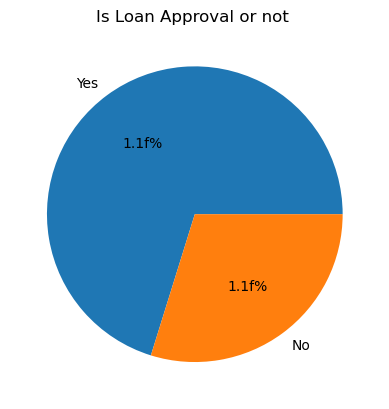

In [89]:
clases_count=df["Loan_Approved"].value_counts()
import matplotlib.pyplot as plt

plt.pie(clases_count,labels=["Yes","No"],autopct="1.1f%%")
plt.title("Is Loan Approval or not ")


[Text(0, 0, '722'), Text(0, 0, '278')]

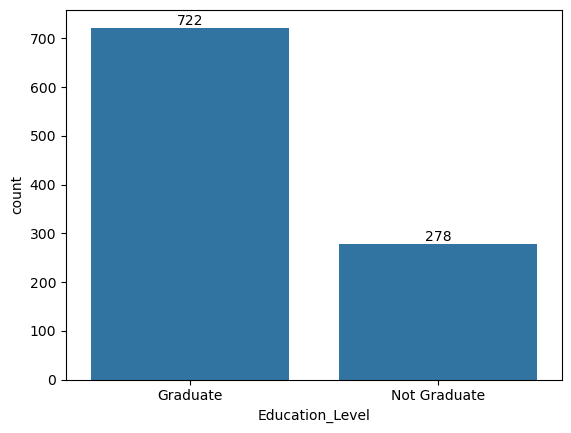

In [90]:
edu_count=df["Education_Level"].value_counts()
ax=sns.barplot(edu_count)
ax.bar_label(ax.containers[0])



Text(0.5, 1.0, 'Propert Area ')

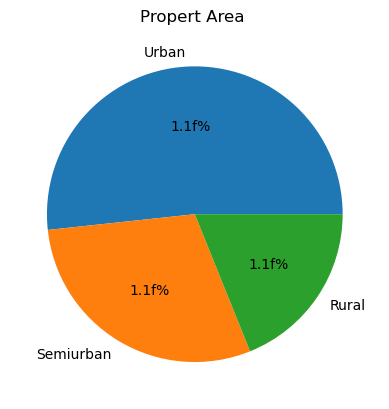

In [91]:
clases_count=df["Property_Area"].value_counts()
import matplotlib.pyplot as plt

plt.pie(clases_count,labels=["Urban","Semiurban","Rural"],autopct="1.1f%%")
plt.title("Propert Area ")


<Axes: xlabel='Applicant_Income', ylabel='Count'>

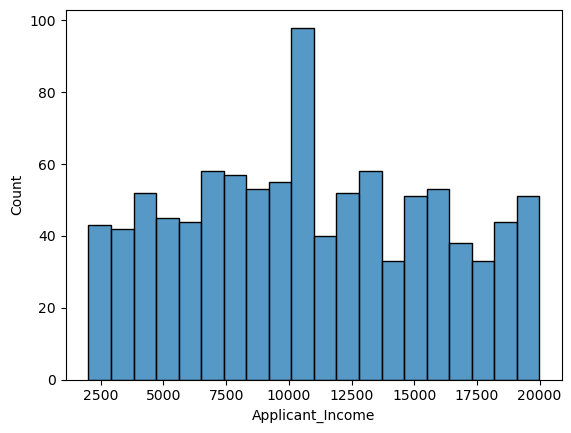

In [92]:
sns.histplot(
    data=df,
    x="Applicant_Income",
   
    bins=20,
   
    
)


<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

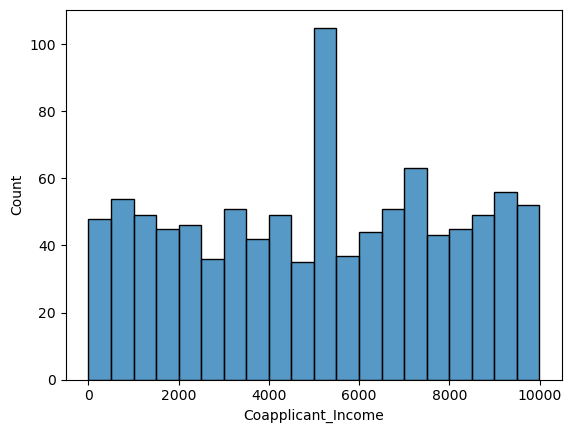

In [93]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
   
    bins=20,
   
    
)


<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

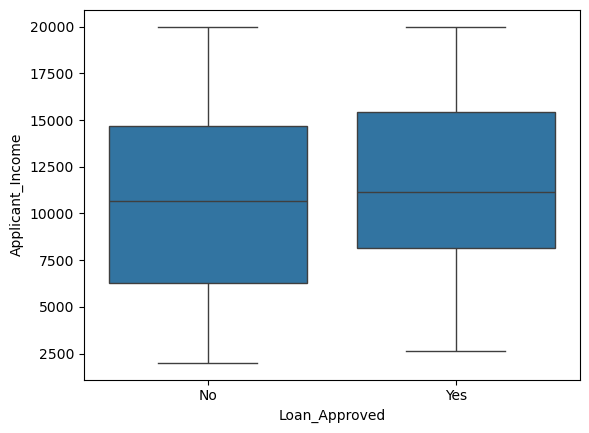

In [94]:
sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)

In [146]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,1,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,1,2.0,721.0,1.0,0.29,9386.0,37629.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

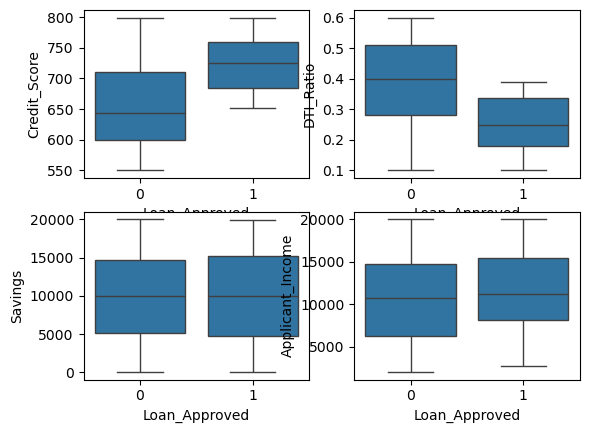

In [147]:
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0] ,data=df,x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[0,1] ,data=df,x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,0] ,data=df,x="Loan_Approved",y="Savings")
sns.boxplot(ax=axes[1,1] ,data=df,x="Loan_Approved",y="Applicant_Income")

<Axes: xlabel='Credit_Score', ylabel='Count'>

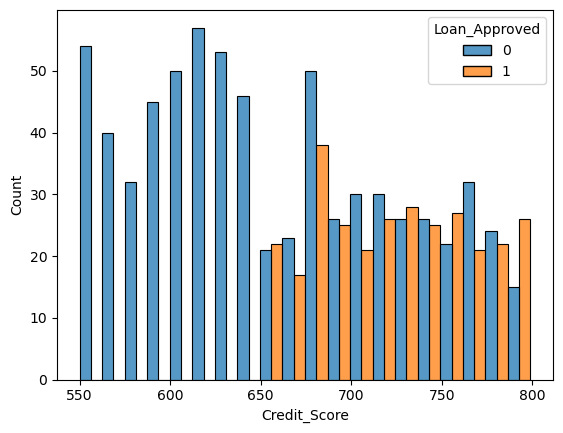

In [148]:
sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple ="dodge"
    
)

# Encoding 

In [149]:

df=df.drop("Applicant_ID",axis=1)
df.sample(10)

KeyError: "['Applicant_ID'] not found in axis"

In [ ]:
df.info()

In [150]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
le=LabelEncoder()
df["Gender"]=le.fit_transform(df["Gender"])
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
df["Marital_Status"]=le.fit_transform(df["Marital_Status"])

In [151]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,...,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,1,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,1,2.0,721.0,1.0,0.29,9386.0,37629.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [152]:
col=["Employment_Status","Loan_Purpose","Property_Area","Employer_Category"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[col])

encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(col),index=df.index)
df=pd.concat([df.drop(columns=col),encoded_df],axis=1)

KeyError: "None of [Index(['Employment_Status', 'Loan_Purpose', 'Property_Area',\n       'Employer_Category'],\n      dtype='object')] are in the [columns]"

In [153]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Marital_Status                   1000 non-null   int64  
 4   Dependents                       1000 non-null   float64
 5   Credit_Score                     1000 non-null   float64
 6   Existing_Loans                   1000 non-null   float64
 7   DTI_Ratio                        1000 non-null   float64
 8   Savings                          1000 non-null   float64
 9   Collateral_Value                 1000 non-null   float64
 10  Loan_Amount                      1000 non-null   float64
 11  Loan_Term                        1000 non-null   float64
 12  Education_Level      

Applicant_Income                   0
Coapplicant_Income                 0
Age                                0
Marital_Status                     0
Dependents                         0
Credit_Score                       0
Existing_Loans                     0
DTI_Ratio                          0
Savings                            0
Collateral_Value                   0
Loan_Amount                        0
Loan_Term                          0
Education_Level                    0
Gender                             0
Loan_Approved                      0
Employment_Status_Salaried         0
Employment_Status_Self-employed    0
Employment_Status_Unemployed       0
Loan_Purpose_Car                   0
Loan_Purpose_Education             0
Loan_Purpose_Home                  0
Loan_Purpose_Personal              0
Property_Area_Semiurban            0
Property_Area_Urban                0
Employer_Category_Government       0
Employer_Category_MNC              0
Employer_Category_Private          0
E

correlation Heatmap

<Axes: >

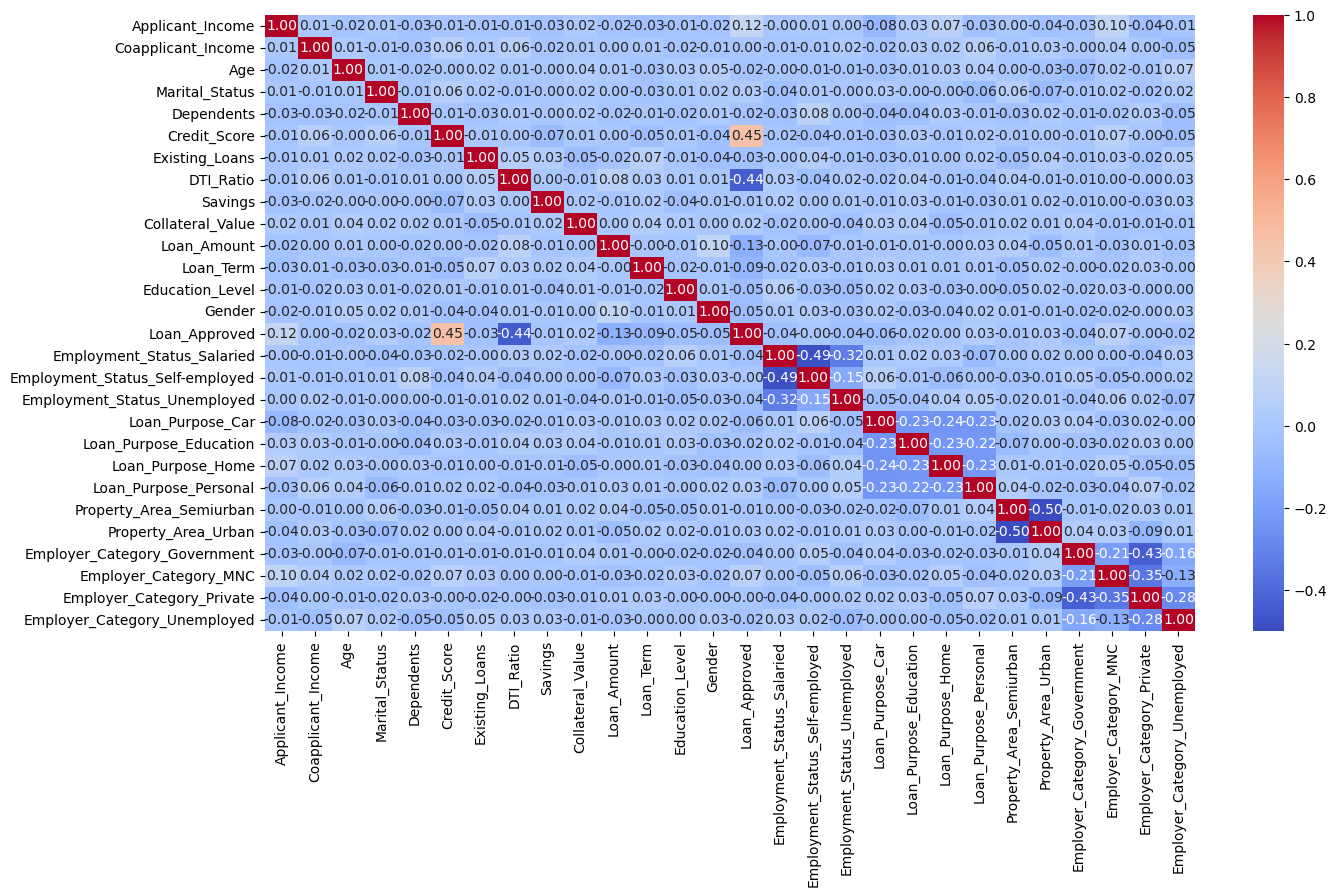

In [154]:
nums_col=df.select_dtypes(include="number")
corr_matrix= nums_col.corr()


plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot =True,
    fmt=".2f",
    cmap="coolwarm"
)

In [155]:

plt.savefig("correlation_heatmap.png")
plt.savefig(
    r"C:\Users\VRUSHALI\OneDrive\Pictures\correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

#Feature Enfinnering Scaling

In [156]:
x=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [157]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [158]:
# Standard Scaling 

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [159]:
x_test_scaled

array([[ 0.42610546,  0.55091079,  1.19037073, ..., -0.41388776,
         1.16316   , -0.30723158],
       [ 1.00971366,  0.58995935,  0.18392964, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.67557096, -0.54558674,  1.09887608, ..., -0.41388776,
         1.16316   , -0.30723158],
       ...,
       [-0.67980585, -0.10106072,  1.28186537, ..., -0.41388776,
         1.16316   , -0.30723158],
       [-0.37650705, -0.97825874, -0.54802752, ..., -0.41388776,
        -0.85972695, -0.30723158],
       [-0.73647272, -1.24497436,  0.73289751, ..., -0.41388776,
         1.16316   , -0.30723158]], shape=(200, 27))

# Train and Evaluate Models

logestic regression 

In [160]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,precision_score,f1_score

In [161]:
model=LogisticRegression()
model.fit(x_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [163]:
y_pred=model.predict(x_test_scaled)
# evaluation

print("accuracy_score : ", accuracy_score(y_test,y_pred))
print("Precision Score : ", precision_score(y_test,y_pred))
print("recall_score : ", recall_score(y_test,y_pred))
print("f1_score : ", f1_score(y_test,y_pred))
print("confussion  metrices  : ", confusion_matrix(y_test,y_pred))


accuracy_score :  0.865
Precision Score :  0.7833333333333333
recall_score :  0.7704918032786885
f1_score :  0.7768595041322314
confussion  metrices  :  [[126  13]
 [ 14  47]]


In [143]:
#(n_) Knn
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(
    n_neighbors=5
)# Number of neighbors to use
knn_model.fit(x_train_scaled,y_train)

y_pred=knn_model.predict(x_test_scaled)

print("accuracy_score : ", accuracy_score(y_test,y_pred))
print("Precision Score : ", precision_score(y_test,y_pred))
print("recall_score : ", recall_score(y_test,y_pred))
print("f1_score : ", f1_score(y_test,y_pred))
print("confussion  metrices  : ", confusion_matrix(y_test,y_pred))



accuracy_score :  0.76
Precision Score :  0.6274509803921569
recall_score :  0.5245901639344263
f1_score :  0.5714285714285714
confussion  metrices  :  [[120  19]
 [ 29  32]]


In [144]:
# naive bayes
from sklearn.naive_bayes import GaussianNB
nb_model=GaussianNB()
nb_model.fit(x_train_scaled,y_train)
y_pred=nb_model.predict(x_test_scaled)

print("accuracy_score : ", accuracy_score(y_test,y_pred))
print("Precision Score : ", precision_score(y_test,y_pred))
print("recall_score : ", recall_score(y_test,y_pred))
print("f1_score : ", f1_score(y_test,y_pred))
print("confussion  metrices  : ", confusion_matrix(y_test,y_pred))



accuracy_score :  0.865
Precision Score :  0.8035714285714286
recall_score :  0.7377049180327869
f1_score :  0.7692307692307693
confussion  metrices  :  [[128  11]
 [ 16  45]]
